# Experiment 7: Dimensionality Reduction and Model Evaluation Using PCA

## 1. Objective

To study the effect of dimensionality reduction using Principal Component Analysis (PCA) on the performance of various machine learning classifiers.

The models are trained and evaluated in two settings:
- Without PCA using the original feature space.
- With PCA using the reduced feature space.

Hyperparameter tuning and 5-fold cross-validation are performed for both settings.

## 2. Dataset

The Breast Cancer Wisconsin (Diagnostic) dataset is used for this experiment.

- Number of samples: 569
- Number of features: 30
- Number of classes: 2
- Target variable: Diagnosis
- Classes: Malignant (M) and Benign (B)

## 3. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 4. Load the Dataset

In [3]:
df=pd.read_csv("wdbc.data",header=None)
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## 5. Assign Column Names

In [4]:
columns = [
    "ID", "Diagnosis",
    "Radius_mean", "Texture_mean", "Perimeter_mean", "Area_mean",
    "Smoothness_mean", "Compactness_mean", "Concavity_mean",
    "Concave_points_mean", "Symmetry_mean", "Fractal_dimension_mean",
    "Radius_se", "Texture_se", "Perimeter_se", "Area_se",
    "Smoothness_se", "Compactness_se", "Concavity_se",
    "Concave_points_se", "Symmetry_se", "Fractal_dimension_se",
    "Radius_worst", "Texture_worst", "Perimeter_worst", "Area_worst",
    "Smoothness_worst", "Compactness_worst", "Concavity_worst",
    "Concave_points_worst", "Symmetry_worst", "Fractal_dimension_worst"
]

df.columns = columns

## 6. Display the First Five Rows

In [5]:
df.head()

,ID,Diagnosis,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,...,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 7. Check the Shape of the Dataset

In [6]:
df.shape

(569, 32)

## 8. Display Dataset Information

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    str    
 2   Radius_mean              569 non-null    float64
 3   Texture_mean             569 non-null    float64
 4   Perimeter_mean           569 non-null    float64
 5   Area_mean                569 non-null    float64
 6   Smoothness_mean          569 non-null    float64
 7   Compactness_mean         569 non-null    float64
 8   Concavity_mean           569 non-null    float64
 9   Concave_points_mean      569 non-null    float64
 10  Symmetry_mean            569 non-null    float64
 11  Fractal_dimension_mean   569 non-null    float64
 12  Radius_se                569 non-null    float64
 13  Texture_se               569 non-null    float64
 14  Perimeter_se             569 non-null

In [9]:
df.describe()
df.isnull().sum()

ID                         0
Diagnosis                  0
Radius_mean                0
Texture_mean               0
Perimeter_mean             0
Area_mean                  0
Smoothness_mean            0
Compactness_mean           0
Concavity_mean             0
Concave_points_mean        0
Symmetry_mean              0
Fractal_dimension_mean     0
Radius_se                  0
Texture_se                 0
Perimeter_se               0
Area_se                    0
Smoothness_se              0
Compactness_se             0
Concavity_se               0
Concave_points_se          0
Symmetry_se                0
Fractal_dimension_se       0
Radius_worst               0
Texture_worst              0
Perimeter_worst            0
Area_worst                 0
Smoothness_worst           0
Compactness_worst          0
Concavity_worst            0
Concave_points_worst       0
Symmetry_worst             0
Fractal_dimension_worst    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## Check Target Class Distribution

In [12]:
df["Diagnosis"].value_counts()

Diagnosis
B    357
M    212
Name: count, dtype: int64

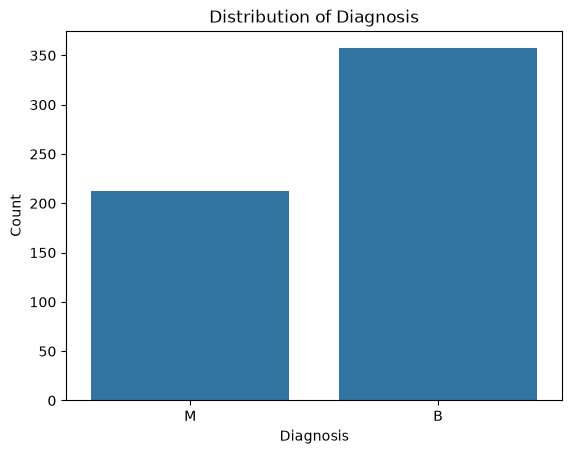

In [13]:
sns.countplot(x="Diagnosis", data=df)

plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

## Remove the ID Column

The ID column is an identifier and is not used as a predictive feature.

In [14]:
df=df.drop("ID",axis=1)

##  Encode the Target Variable

The target variable contains:
- M = Malignant
- B = Benign

In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Diagnosis"]=le.fit_transform(df["Diagnosis"])

##  Separate Features and Target

In [16]:
X=df.drop("Diagnosis",axis=1)
Y=df["Diagnosis"]

print(X.shape)
print(Y.shape)

(569, 30)
(569,)


## Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)


## Standardize the Features

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  Principal Component Analysis (PCA)

PCA is applied to the standardized training data to reduce the dimensionality of the feature space while retaining maximum variance.

In [35]:
from sklearn.decomposition import PCA
pca=PCA()
x_train_pca=pca.fit_transform(X_train_scaled)

##  Explained Variance Ratio

The explained variance ratio shows the proportion of total variance captured by each principal component.

In [36]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[4.45935222e-01 1.85452555e-01 9.58464121e-02 6.59376825e-02
 5.62228616e-02 3.98848772e-02 2.21449317e-02 1.61400564e-02
 1.28478896e-02 1.16566138e-02 1.00835994e-02 9.05534747e-03
 7.92635285e-03 4.79482101e-03 3.04107016e-03 2.51299401e-03
 1.97524871e-03 1.74413404e-03 1.57346560e-03 1.05152270e-03
 9.95539341e-04 7.95814888e-04 7.84034550e-04 5.31246275e-04
 5.11862282e-04 2.64113057e-04 2.09992404e-04 5.03306942e-05
 2.52827614e-05 4.12638742e-06]


##  Cumulative Explained Variance

The cumulative explained variance represents the total variance retained when multiple principal components are considered together.

In [37]:
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.44593522 0.63138778 0.72723419 0.79317187 0.84939473 0.88927961
 0.91142454 0.9275646  0.94041249 0.9520691  0.9621527  0.97120805
 0.9791344  0.98392922 0.98697029 0.98948329 0.99145854 0.99320267
 0.99477613 0.99582766 0.9968232  0.99761901 0.99840305 0.99893429
 0.99944615 0.99971027 0.99992026 0.99997059 0.99999587 1.        ]


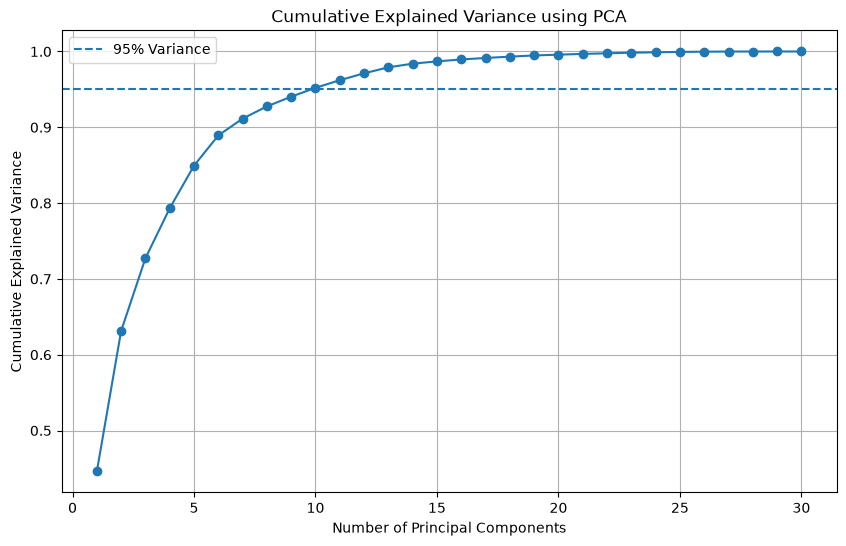

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance using PCA")

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.legend()
plt.grid()
plt.show()

##  Select Number of Components for 95% Variance

The number of principal components required to retain at least 95% of the total variance is determined from the cumulative explained variance.

In [39]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components required for 95% variance:", n_components)

Number of components required for 95% variance: 10


In [40]:
pca_table = pd.DataFrame({
    "Principal Component": range(1, len(explained_variance) + 1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

pca_table

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.445935,0.445935
1,2,0.185453,0.631388
2,3,0.095846,0.727234
3,4,0.065938,0.793172
4,5,0.056223,0.849395
5,6,0.039885,0.889280
6,7,0.022145,0.911425
7,8,0.016140,0.927565
8,9,0.012848,0.940412
9,10,0.011657,0.952069


##  Scree Plot

The scree plot shows the explained variance contributed by each principal component.

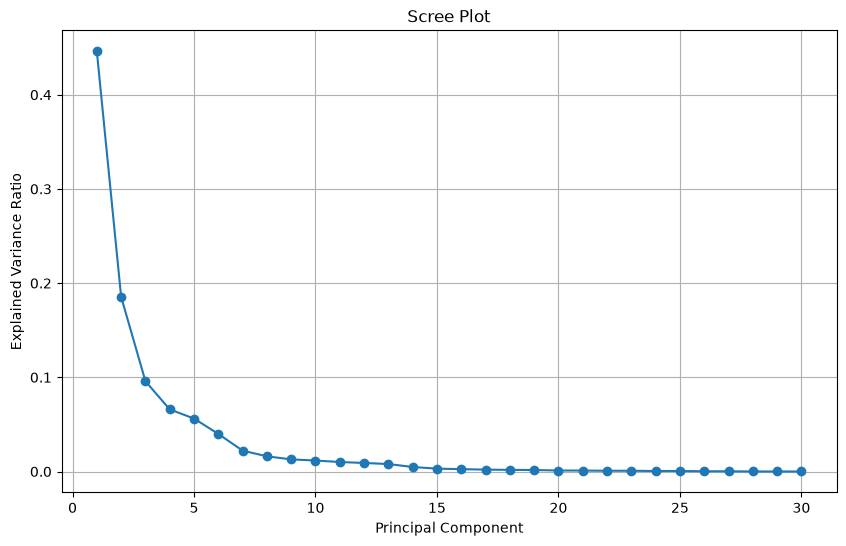

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid()
plt.show()

##  Apply PCA with Selected Number of Components

PCA is applied again using the number of components required to retain at least 95% of the variance.

In [42]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("X_train_scaled contains NaN:", np.isnan(X_train_scaled).any())
print("X_test_scaled contains NaN:", np.isnan(X_test_scaled).any())

print("X_train_scaled contains infinite values:", np.isinf(X_train_scaled).any())
print("X_test_scaled contains infinite values:", np.isinf(X_test_scaled).any())

X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)
X_train_scaled contains NaN: False
X_test_scaled contains NaN: False
X_train_scaled contains infinite values: False
X_test_scaled contains infinite values: False


In [43]:
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [44]:
print("Original training shape:", X_train_scaled.shape)
print("PCA training shape:", X_train_pca.shape)

print("Original testing shape:", X_test_scaled.shape)
print("PCA testing shape:", X_test_pca.shape)

Original training shape: (455, 30)
PCA training shape: (455, 10)
Original testing shape: (114, 30)
PCA testing shape: (114, 10)


##  Support Vector Machine (SVM)

Support Vector Machine (SVM) is used for binary classification. Hyperparameter tuning is performed using 5-fold cross-validation for both the original feature space (No-PCA) and the PCA-reduced feature space (With-PCA).

In [45]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

##  Define SVM Hyperparameter Grid

The hyperparameters considered for SVM are:
- C
- Kernel
- Gamma

In [47]:
svm_params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

##  SVM Hyperparameter Tuning Without PCA

GridSearchCV with 5-fold cross-validation is used to identify the best SVM hyperparameters using the original 30 standardized features.

In [49]:
svm_grid_no_pca = GridSearchCV(
    estimator=SVC(),
    param_grid=svm_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pr

In [50]:
print("Best parameters:", svm_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", svm_grid_no_pca.best_score_)

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best 5-fold CV accuracy: 0.9758241758241759


In [51]:
## 27. Fold-wise SVM Accuracy Without PCA

In [52]:
cv_results_no_pca = pd.DataFrame(svm_grid_no_pca.cv_results_)

best_index_no_pca = svm_grid_no_pca.best_index_

print("Fold 1:", cv_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", cv_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", cv_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", cv_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", cv_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", cv_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 0.967032967032967
Fold 2: 1.0
Fold 3: 0.967032967032967
Fold 4: 0.967032967032967
Fold 5: 0.978021978021978
Average: 0.9758241758241759


#  SVM Hyperparameter Tuning With PCA

GridSearchCV with 5-fold cross-validation is used to identify the best SVM hyperparameters using the 10 PCA components.

In [54]:
svm_grid_pca = GridSearchCV(
    estimator=SVC(),
    param_grid=svm_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pr

In [55]:
print("Best parameters:", svm_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", svm_grid_pca.best_score_)

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best 5-fold CV accuracy: 0.9758241758241759


In [57]:
cv_results_pca = pd.DataFrame(svm_grid_pca.cv_results_)

best_index_pca = svm_grid_pca.best_index_

print("Fold 1:", cv_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", cv_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", cv_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", cv_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", cv_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", cv_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.967032967032967
Fold 2: 1.0
Fold 3: 0.967032967032967
Fold 4: 0.978021978021978
Fold 5: 0.967032967032967
Average: 0.9758241758241759


##  SVM Performance Comparison

The cross-validation performance of SVM is compared between the original feature space and the PCA-reduced feature space.

In [59]:
svm_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        svm_grid_no_pca.best_score_,
        svm_grid_pca.best_score_
    ]
})

svm_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.975824
1,With-PCA,10,0.975824


In [60]:
print("SVM No-PCA Best Parameters:", svm_grid_no_pca.best_params_)
print("SVM No-PCA Average Accuracy:", svm_grid_no_pca.best_score_)

print()

print("SVM With-PCA Best Parameters:", svm_grid_pca.best_params_)
print("SVM With-PCA Average Accuracy:", svm_grid_pca.best_score_)

SVM No-PCA Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM No-PCA Average Accuracy: 0.9758241758241759

SVM With-PCA Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
SVM With-PCA Average Accuracy: 0.9758241758241759


##  Naïve Bayes

Naïve Bayes is used for binary classification. The model is evaluated using 5-fold cross-validation in both the original feature space (No-PCA) and the PCA-reduced feature space (With-PCA).

In [61]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

In [62]:
nb_params = {
    "var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

##  Naïve Bayes Hyperparameter Tuning Without PCA

GridSearchCV with 5-fold cross-validation is used to select the best value of var_smoothing using the original 30 standardized features.

In [63]:
nb_grid_no_pca = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=nb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

nb_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-11, 1e-10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highe

In [64]:
print("Best parameters:", nb_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", nb_grid_no_pca.best_score_)

Best parameters: {'var_smoothing': 1e-11}
Best 5-fold CV accuracy: 0.9384615384615385


In [65]:
nb_results_no_pca = pd.DataFrame(nb_grid_no_pca.cv_results_)

best_index_no_pca = nb_grid_no_pca.best_index_

print("Fold 1:", nb_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", nb_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", nb_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", nb_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", nb_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", nb_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 0.9230769230769231
Fold 2: 0.989010989010989
Fold 3: 0.9230769230769231
Fold 4: 0.9230769230769231
Fold 5: 0.9340659340659341
Average: 0.9384615384615385


## Naïve Bayes Hyperparameter Tuning With PCA

GridSearchCV with 5-fold cross-validation is used to select the best value of var_smoothing using the PCA-reduced feature space.

In [66]:
nb_grid_pca = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=nb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

nb_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-11, 1e-10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highe

In [67]:
print("Best parameters:", nb_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", nb_grid_pca.best_score_)

Best parameters: {'var_smoothing': 1e-11}
Best 5-fold CV accuracy: 0.9208791208791208


In [68]:
nb_results_pca = pd.DataFrame(nb_grid_pca.cv_results_)

best_index_pca = nb_grid_pca.best_index_

print("Fold 1:", nb_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", nb_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", nb_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", nb_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", nb_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", nb_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.9010989010989011
Fold 2: 0.978021978021978
Fold 3: 0.9340659340659341
Fold 4: 0.9010989010989011
Fold 5: 0.8901098901098901
Average: 0.9208791208791208


In [69]:
nb_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        nb_grid_no_pca.best_score_,
        nb_grid_pca.best_score_
    ]
})

nb_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.938462
1,With-PCA,10,0.920879


In [70]:
print("Naïve Bayes No-PCA Best Parameters:", nb_grid_no_pca.best_params_)
print("Naïve Bayes No-PCA Average Accuracy:", nb_grid_no_pca.best_score_)

print()

print("Naïve Bayes With-PCA Best Parameters:", nb_grid_pca.best_params_)
print("Naïve Bayes With-PCA Average Accuracy:", nb_grid_pca.best_score_)

Naïve Bayes No-PCA Best Parameters: {'var_smoothing': 1e-11}
Naïve Bayes No-PCA Average Accuracy: 0.9384615384615385

Naïve Bayes With-PCA Best Parameters: {'var_smoothing': 1e-11}
Naïve Bayes With-PCA Average Accuracy: 0.9208791208791208


##  K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is used for binary classification. Hyperparameter tuning is performed using 5-fold cross-validation for both the original feature space (No-PCA) and the PCA-reduced feature space (With-PCA).

In [71]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [72]:
knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

##  KNN Hyperparameter Tuning Without PCA

GridSearchCV with 5-fold cross-validation is used to select the best KNN hyperparameters using the original 30 standardized features.

In [73]:
knn_grid_no_pca = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [74]:
print("Best parameters:", knn_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", knn_grid_no_pca.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best 5-fold CV accuracy: 0.9692307692307693


In [75]:
knn_results_no_pca = pd.DataFrame(knn_grid_no_pca.cv_results_)

best_index_no_pca = knn_grid_no_pca.best_index_

print("Fold 1:", knn_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", knn_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", knn_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", knn_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", knn_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", knn_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 0.978021978021978
Fold 2: 1.0
Fold 3: 0.945054945054945
Fold 4: 0.978021978021978
Fold 5: 0.945054945054945
Average: 0.9692307692307693


##  KNN Hyperparameter Tuning With PCA

GridSearchCV with 5-fold cross-validation is used to select the best KNN hyperparameters using the PCA-reduced feature space.

In [76]:
knn_grid_pca = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [77]:
print("Best parameters:", knn_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", knn_grid_pca.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best 5-fold CV accuracy: 0.9670329670329672


In [78]:
knn_results_pca = pd.DataFrame(knn_grid_pca.cv_results_)

best_index_pca = knn_grid_pca.best_index_

print("Fold 1:", knn_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", knn_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", knn_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", knn_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", knn_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", knn_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.967032967032967
Fold 2: 1.0
Fold 3: 0.945054945054945
Fold 4: 0.978021978021978
Fold 5: 0.945054945054945
Average: 0.9670329670329672


In [79]:
knn_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        knn_grid_no_pca.best_score_,
        knn_grid_pca.best_score_
    ]
})

knn_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.969231
1,With-PCA,10,0.967033


In [80]:
print("KNN No-PCA Best Parameters:", knn_grid_no_pca.best_params_)
print("KNN No-PCA Average Accuracy:", knn_grid_no_pca.best_score_)

print()

print("KNN With-PCA Best Parameters:", knn_grid_pca.best_params_)
print("KNN With-PCA Average Accuracy:", knn_grid_pca.best_score_)

KNN No-PCA Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
KNN No-PCA Average Accuracy: 0.9692307692307693

KNN With-PCA Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
KNN With-PCA Average Accuracy: 0.9670329670329672


## Logistic Regression

Logistic Regression is used for binary classification. Hyperparameter tuning is performed using 5-fold cross-validation for both the original feature space (No-PCA) and the PCA-reduced feature space (With-PCA).

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [82]:
lr_params = {
    "C": [0.01, 0.1, 1, 10, 100]
}

##  Logistic Regression Hyperparameter Tuning Without PCA

GridSearchCV with 5-fold cross-validation is used to select the best Logistic Regression hyperparameter using the original 30 standardized features.

In [83]:
lr_grid_no_pca = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),
    param_grid=lr_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=5000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hi

In [84]:
print("Best parameters:", lr_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", lr_grid_no_pca.best_score_)

Best parameters: {'C': 1}
Best 5-fold CV accuracy: 0.9714285714285715


In [85]:
lr_results_no_pca = pd.DataFrame(lr_grid_no_pca.cv_results_)

best_index_no_pca = lr_grid_no_pca.best_index_

print("Fold 1:", lr_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", lr_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", lr_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", lr_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", lr_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", lr_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 0.967032967032967
Fold 2: 0.989010989010989
Fold 3: 0.9560439560439561
Fold 4: 0.978021978021978
Fold 5: 0.967032967032967
Average: 0.9714285714285715


## Logistic Regression Hyperparameter Tuning With PCA

GridSearchCV with 5-fold cross-validation is used to select the best Logistic Regression hyperparameter using the PCA-reduced feature space.

In [86]:
lr_grid_pca = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),
    param_grid=lr_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=5000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hi

In [87]:
print("Best parameters:", lr_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", lr_grid_pca.best_score_)

Best parameters: {'C': 1}
Best 5-fold CV accuracy: 0.9758241758241759


In [88]:
lr_results_pca = pd.DataFrame(lr_grid_pca.cv_results_)

best_index_pca = lr_grid_pca.best_index_

print("Fold 1:", lr_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", lr_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", lr_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", lr_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", lr_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", lr_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.967032967032967
Fold 2: 1.0
Fold 3: 0.967032967032967
Fold 4: 0.978021978021978
Fold 5: 0.967032967032967
Average: 0.9758241758241759


In [89]:
lr_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        lr_grid_no_pca.best_score_,
        lr_grid_pca.best_score_
    ]
})

lr_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.971429
1,With-PCA,10,0.975824


In [90]:
print("Logistic Regression No-PCA Best Parameters:", lr_grid_no_pca.best_params_)
print("Logistic Regression No-PCA Average Accuracy:", lr_grid_no_pca.best_score_)

print()

print("Logistic Regression With-PCA Best Parameters:", lr_grid_pca.best_params_)
print("Logistic Regression With-PCA Average Accuracy:", lr_grid_pca.best_score_)

Logistic Regression No-PCA Best Parameters: {'C': 1}
Logistic Regression No-PCA Average Accuracy: 0.9714285714285715

Logistic Regression With-PCA Best Parameters: {'C': 1}
Logistic Regression With-PCA Average Accuracy: 0.9758241758241759


In [91]:
## 63. Decision Tree

Decision Tree is used for binary classification. Hyperparameter tuning is performed using 5-fold cross-validation for both the original feature space (No-PCA) and the PCA-reduced feature space (With-PCA).

SyntaxError: invalid syntax (2273562164.py, line 3)

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [93]:
dt_params = {
    "max_depth": [None, 3, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [94]:
## 65. Decision Tree Hyperparameter Tuning Without PCA

GridSearchCV with 5-fold cross-validation is used to select the best Decision Tree hyperparameters using the original 30 standardized features.

SyntaxError: invalid syntax (2725948462.py, line 3)

In [95]:
dt_grid_no_pca = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

In [97]:
print("Best parameters:", dt_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", dt_grid_no_pca.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best 5-fold CV accuracy: 0.9384615384615385


In [98]:
dt_results_no_pca = pd.DataFrame(dt_grid_no_pca.cv_results_)

best_index_no_pca = dt_grid_no_pca.best_index_

print("Fold 1:", dt_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", dt_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", dt_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", dt_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", dt_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", dt_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 0.978021978021978
Fold 2: 0.9560439560439561
Fold 3: 0.9120879120879121
Fold 4: 0.967032967032967
Fold 5: 0.8791208791208791
Average: 0.9384615384615385


In [99]:
dt_grid_pca = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

In [100]:
print("Best parameters:", dt_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", dt_grid_pca.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best 5-fold CV accuracy: 0.9340659340659341


In [101]:
dt_results_pca = pd.DataFrame(dt_grid_pca.cv_results_)

best_index_pca = dt_grid_pca.best_index_

print("Fold 1:", dt_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", dt_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", dt_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", dt_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", dt_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", dt_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.8901098901098901
Fold 2: 0.967032967032967
Fold 3: 0.9230769230769231
Fold 4: 0.967032967032967
Fold 5: 0.9230769230769231
Average: 0.9340659340659341


In [102]:
dt_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        dt_grid_no_pca.best_score_,
        dt_grid_pca.best_score_
    ]
})

dt_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.938462
1,With-PCA,10,0.934066


In [103]:
print("Decision Tree No-PCA Best Parameters:", dt_grid_no_pca.best_params_)
print("Decision Tree No-PCA Average Accuracy:", dt_grid_no_pca.best_score_)

print()

print("Decision Tree With-PCA Best Parameters:", dt_grid_pca.best_params_)
print("Decision Tree With-PCA Average Accuracy:", dt_grid_pca.best_score_)

Decision Tree No-PCA Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Decision Tree No-PCA Average Accuracy: 0.9384615384615385

Decision Tree With-PCA Best Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Decision Tree With-PCA Average Accuracy: 0.9340659340659341


In [104]:
##  Random Forest

Random Forest is an ensemble classification algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting. Hyperparameter tuning is performed using 5-fold cross-validation for both the original feature space (No-PCA) and the PCA-reduced feature space (With-PCA).

SyntaxError: invalid syntax (3610917110.py, line 3)

In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [106]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

In [107]:
rf_grid_no_pca = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [108]:
print("Best parameters:", rf_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", rf_grid_no_pca.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best 5-fold CV accuracy: 0.9626373626373628


In [109]:
rf_results_no_pca = pd.DataFrame(rf_grid_no_pca.cv_results_)

best_index_no_pca = rf_grid_no_pca.best_index_

print("Fold 1:", rf_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", rf_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", rf_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", rf_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", rf_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", rf_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 1.0
Fold 2: 0.989010989010989
Fold 3: 0.9340659340659341
Fold 4: 0.978021978021978
Fold 5: 0.9120879120879121
Average: 0.9626373626373628


In [110]:
rf_grid_pca = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [111]:
print("Best parameters:", rf_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", rf_grid_pca.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best 5-fold CV accuracy: 0.9582417582417582


In [112]:
rf_results_pca = pd.DataFrame(rf_grid_pca.cv_results_)

best_index_pca = rf_grid_pca.best_index_

print("Fold 1:", rf_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", rf_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", rf_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", rf_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", rf_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", rf_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.9120879120879121
Fold 2: 1.0
Fold 3: 0.945054945054945
Fold 4: 0.967032967032967
Fold 5: 0.967032967032967
Average: 0.9582417582417582


In [113]:
rf_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        rf_grid_no_pca.best_score_,
        rf_grid_pca.best_score_
    ]
})

rf_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.962637
1,With-PCA,10,0.958242


In [114]:
print("Random Forest No-PCA Best Parameters:", rf_grid_no_pca.best_params_)
print("Random Forest No-PCA Average Accuracy:", rf_grid_no_pca.best_score_)

print()

print("Random Forest With-PCA Best Parameters:", rf_grid_pca.best_params_)
print("Random Forest With-PCA Average Accuracy:", rf_grid_pca.best_score_)

Random Forest No-PCA Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest No-PCA Average Accuracy: 0.9626373626373628

Random Forest With-PCA Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest With-PCA Average Accuracy: 0.9582417582417582


##  AdaBoost

AdaBoost is an ensemble classification algorithm that combines multiple weak learners to build a stronger classifier. Hyperparameter tuning is performed using 5-fold cross-validation for both the original feature space (No-PCA) and the PCA-reduced feature space (With-PCA).

In [115]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

In [116]:
ada_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0]
}

In [117]:
ada_grid_no_pca = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=ada_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

ada_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of

In [118]:
print("Best parameters:", ada_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", ada_grid_no_pca.best_score_)

Best parameters: {'learning_rate': 1.0, 'n_estimators': 200}
Best 5-fold CV accuracy: 0.964835164835165


In [119]:
ada_results_no_pca = pd.DataFrame(ada_grid_no_pca.cv_results_)

best_index_no_pca = ada_grid_no_pca.best_index_

print("Fold 1:", ada_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", ada_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", ada_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", ada_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", ada_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", ada_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 0.989010989010989
Fold 2: 1.0
Fold 3: 0.9230769230769231
Fold 4: 0.978021978021978
Fold 5: 0.9340659340659341
Average: 0.964835164835165


In [120]:
ada_grid_pca = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=ada_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

ada_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of

In [121]:
print("Best parameters:", ada_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", ada_grid_pca.best_score_)

Best parameters: {'learning_rate': 1.0, 'n_estimators': 50}
Best 5-fold CV accuracy: 0.9648351648351647


In [122]:
ada_results_pca = pd.DataFrame(ada_grid_pca.cv_results_)

best_index_pca = ada_grid_pca.best_index_

print("Fold 1:", ada_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", ada_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", ada_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", ada_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", ada_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", ada_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.945054945054945
Fold 2: 0.989010989010989
Fold 3: 0.945054945054945
Fold 4: 0.989010989010989
Fold 5: 0.9560439560439561
Average: 0.9648351648351647


In [123]:
ada_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        ada_grid_no_pca.best_score_,
        ada_grid_pca.best_score_
    ]
})

ada_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.964835
1,With-PCA,10,0.964835


In [124]:
print("AdaBoost No-PCA Best Parameters:", ada_grid_no_pca.best_params_)
print("AdaBoost No-PCA Average Accuracy:", ada_grid_no_pca.best_score_)

print()

print("AdaBoost With-PCA Best Parameters:", ada_grid_pca.best_params_)
print("AdaBoost With-PCA Average Accuracy:", ada_grid_pca.best_score_)

AdaBoost No-PCA Best Parameters: {'learning_rate': 1.0, 'n_estimators': 200}
AdaBoost No-PCA Average Accuracy: 0.964835164835165

AdaBoost With-PCA Best Parameters: {'learning_rate': 1.0, 'n_estimators': 50}
AdaBoost With-PCA Average Accuracy: 0.9648351648351647


##  Gradient Boosting

Gradient Boosting is an ensemble classification algorithm that builds a sequence of weak learners, where each new learner attempts to correct the errors made by the previous learners. Hyperparameter tuning is performed using 5-fold cross-validation for both the original feature space (No-PCA) and the PCA-reduced feature space (With-PCA).

In [125]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [126]:
gb_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 5]
}

In [127]:
gb_grid_no_pca = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=

In [128]:
print("Best parameters:", gb_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", gb_grid_no_pca.best_score_)

Best parameters: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100}
Best 5-fold CV accuracy: 0.9604395604395606


In [129]:
gb_results_no_pca = pd.DataFrame(gb_grid_no_pca.cv_results_)

best_index_no_pca = gb_grid_no_pca.best_index_

print("Fold 1:", gb_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", gb_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", gb_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", gb_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", gb_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", gb_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 1.0
Fold 2: 0.978021978021978
Fold 3: 0.9340659340659341
Fold 4: 0.967032967032967
Fold 5: 0.9230769230769231
Average: 0.9604395604395606


In [130]:
gb_grid_pca = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=

In [131]:
print("Best parameters:", gb_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", gb_grid_pca.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
Best 5-fold CV accuracy: 0.956043956043956


In [132]:
gb_results_pca = pd.DataFrame(gb_grid_pca.cv_results_)

best_index_pca = gb_grid_pca.best_index_

print("Fold 1:", gb_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", gb_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", gb_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", gb_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", gb_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", gb_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.9010989010989011
Fold 2: 1.0
Fold 3: 0.945054945054945
Fold 4: 0.967032967032967
Fold 5: 0.967032967032967
Average: 0.956043956043956


In [133]:
gb_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        gb_grid_no_pca.best_score_,
        gb_grid_pca.best_score_
    ]
})

gb_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.960440
1,With-PCA,10,0.956044


In [134]:
print("Gradient Boosting No-PCA Best Parameters:", gb_grid_no_pca.best_params_)
print("Gradient Boosting No-PCA Average Accuracy:", gb_grid_no_pca.best_score_)

print()

print("Gradient Boosting With-PCA Best Parameters:", gb_grid_pca.best_params_)
print("Gradient Boosting With-PCA Average Accuracy:", gb_grid_pca.best_score_)

Gradient Boosting No-PCA Best Parameters: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100}
Gradient Boosting No-PCA Average Accuracy: 0.9604395604395606

Gradient Boosting With-PCA Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
Gradient Boosting With-PCA Average Accuracy: 0.956043956043956


## XGBoost

In [136]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   -- ------------------------------------- 3.7/48.9 MB 20.1 MB/s eta 0:00:03
   ---- ----------------------------------- 6.0/48.9 MB 14.8 MB/s eta 0:00:03
   ------- -------------------------------- 8.7/48.9 MB 14.2 MB/s eta 0:00:03
   -------- ------------------------------- 10.5/48.9 MB 12.4 MB/s eta 0:00:04
   ---------- ----------------------------- 12.8/48.9 MB 12.3 MB/s eta 0:00:03
   ------------ --------------------------- 14.9/48.9 MB 11.7 MB/s eta 0:00:03
   ------------- -------------------------- 16.8/48.9 MB 11.3 MB/s eta 0:00:03
   --------------- ------------------------ 19.4/48.9 MB 11.4 MB/s eta 0:00:03
   ------------------ --------------------- 22.5/48.9 MB 11.8 MB/s eta 0:00:03
   --------------------- ------------------ 26.2/48.9 MB 12.3 MB/s eta 0:00:02
   ------------------------ --------------- 29.9/48.9 MB 12.7 MB/s eta 0:00:02
   -------------------------- ------------- 33.0/48.9 MB 12.8 MB

In [137]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [138]:
xgb_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

In [139]:
xgb_grid_no_pca = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_grid=xgb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defaul

In [140]:
print("Best parameters:", xgb_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", xgb_grid_no_pca.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best 5-fold CV accuracy: 0.9714285714285715


In [141]:
xgb_results_no_pca = pd.DataFrame(xgb_grid_no_pca.cv_results_)

best_index_no_pca = xgb_grid_no_pca.best_index_

print("Fold 1:", xgb_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", xgb_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", xgb_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", xgb_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", xgb_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", xgb_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 0.978021978021978
Fold 2: 1.0
Fold 3: 0.9340659340659341
Fold 4: 1.0
Fold 5: 0.945054945054945
Average: 0.9714285714285715


In [142]:
xgb_grid_pca = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_grid=xgb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defaul

In [143]:
print("Best parameters:", xgb_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", xgb_grid_pca.best_score_)

Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best 5-fold CV accuracy: 0.9692307692307691


In [146]:
xgb_results_pca = pd.DataFrame(xgb_grid_pca.cv_results_)

best_index_pca = xgb_grid_pca.best_index_

print("Fold 1:", xgb_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", xgb_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", xgb_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", xgb_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", xgb_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", xgb_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.9340659340659341
Fold 2: 1.0
Fold 3: 0.9560439560439561
Fold 4: 0.978021978021978
Fold 5: 0.978021978021978
Average: 0.9692307692307691


In [147]:
xgb_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        xgb_grid_no_pca.best_score_,
        xgb_grid_pca.best_score_
    ]
})

xgb_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.971429
1,With-PCA,10,0.969231


In [148]:
print("XGBoost No-PCA Best Parameters:", xgb_grid_no_pca.best_params_)
print("XGBoost No-PCA Average Accuracy:", xgb_grid_no_pca.best_score_)

print()

print("XGBoost With-PCA Best Parameters:", xgb_grid_pca.best_params_)
print("XGBoost With-PCA Average Accuracy:", xgb_grid_pca.best_score_)

XGBoost No-PCA Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
XGBoost No-PCA Average Accuracy: 0.9714285714285715

XGBoost With-PCA Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
XGBoost With-PCA Average Accuracy: 0.9692307692307691


##  Stacking Classifier

Stacking combines multiple base learners and a meta-learner to produce the final prediction. In this experiment, SVM, KNN, and Random Forest are used as base learners, while Logistic Regression is used as the meta-learner.

The Stacking Classifier is evaluated using 5-fold cross-validation for both the original feature space (No-PCA) and the PCA-reduced feature space (With-PCA).

In [149]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [150]:
base_learners = [
    ("svm", SVC()),
    ("knn", KNeighborsClassifier()),
    ("rf", RandomForestClassifier(random_state=42))
]

meta_learner = LogisticRegression(max_iter=5000)

In [151]:
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)

In [152]:
stacking_params = {
    "final_estimator__C": [0.01, 0.1, 1, 10, 100]
}

In [153]:
stacking_grid_no_pca = GridSearchCV(
    estimator=stacking_model,
    param_grid=stacking_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

stacking_grid_no_pca.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",StackingClass... n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'final_estimator__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [154]:
print("Best parameters:", stacking_grid_no_pca.best_params_)
print("Best 5-fold CV accuracy:", stacking_grid_no_pca.best_score_)

Best parameters: {'final_estimator__C': 0.1}
Best 5-fold CV accuracy: 0.9736263736263737


In [155]:
stacking_results_no_pca = pd.DataFrame(
    stacking_grid_no_pca.cv_results_
)

best_index_no_pca = stacking_grid_no_pca.best_index_

print("Fold 1:", stacking_results_no_pca.loc[best_index_no_pca, "split0_test_score"])
print("Fold 2:", stacking_results_no_pca.loc[best_index_no_pca, "split1_test_score"])
print("Fold 3:", stacking_results_no_pca.loc[best_index_no_pca, "split2_test_score"])
print("Fold 4:", stacking_results_no_pca.loc[best_index_no_pca, "split3_test_score"])
print("Fold 5:", stacking_results_no_pca.loc[best_index_no_pca, "split4_test_score"])
print("Average:", stacking_results_no_pca.loc[best_index_no_pca, "mean_test_score"])

Fold 1: 0.978021978021978
Fold 2: 1.0
Fold 3: 0.967032967032967
Fold 4: 0.967032967032967
Fold 5: 0.9560439560439561
Average: 0.9736263736263737


In [156]:
stacking_grid_pca = GridSearchCV(
    estimator=stacking_model,
    param_grid=stacking_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

stacking_grid_pca.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",StackingClass... n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'final_estimator__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [157]:
print("Best parameters:", stacking_grid_pca.best_params_)
print("Best 5-fold CV accuracy:", stacking_grid_pca.best_score_)

Best parameters: {'final_estimator__C': 1}
Best 5-fold CV accuracy: 0.9692307692307693


In [158]:
stacking_results_pca = pd.DataFrame(
    stacking_grid_pca.cv_results_
)

best_index_pca = stacking_grid_pca.best_index_

print("Fold 1:", stacking_results_pca.loc[best_index_pca, "split0_test_score"])
print("Fold 2:", stacking_results_pca.loc[best_index_pca, "split1_test_score"])
print("Fold 3:", stacking_results_pca.loc[best_index_pca, "split2_test_score"])
print("Fold 4:", stacking_results_pca.loc[best_index_pca, "split3_test_score"])
print("Fold 5:", stacking_results_pca.loc[best_index_pca, "split4_test_score"])
print("Average:", stacking_results_pca.loc[best_index_pca, "mean_test_score"])

Fold 1: 0.967032967032967
Fold 2: 1.0
Fold 3: 0.967032967032967
Fold 4: 0.967032967032967
Fold 5: 0.945054945054945
Average: 0.9692307692307693


In [159]:
stacking_comparison = pd.DataFrame({
    "Setting": ["No-PCA", "With-PCA"],
    "Number of Features": [30, n_components],
    "Average CV Accuracy": [
        stacking_grid_no_pca.best_score_,
        stacking_grid_pca.best_score_
    ]
})

stacking_comparison

,Setting,Number of Features,Average CV Accuracy
0,No-PCA,30,0.973626
1,With-PCA,10,0.969231


In [160]:
print(
    "Stacking No-PCA Best Parameters:",
    stacking_grid_no_pca.best_params_
)

print(
    "Stacking No-PCA Average Accuracy:",
    stacking_grid_no_pca.best_score_
)

print()

print(
    "Stacking With-PCA Best Parameters:",
    stacking_grid_pca.best_params_
)

print(
    "Stacking With-PCA Average Accuracy:",
    stacking_grid_pca.best_score_
)

Stacking No-PCA Best Parameters: {'final_estimator__C': 0.1}
Stacking No-PCA Average Accuracy: 0.9736263736263737

Stacking With-PCA Best Parameters: {'final_estimator__C': 1}
Stacking With-PCA Average Accuracy: 0.9692307692307693
